# 02 - Modelling : XGBoost et strategies de resampling

Objectif : comparer plusieurs strategies de modelisation sur le dataset IEEE-CIS Fraud Detection avec des metriques adaptees a la fraude.

Ce notebook repond a la question metier : **le modele fait-il mieux qu'une baseline naive, et quelle strategie recommander au CDO ?**

On compare :
- XGBoost brut ;
- XGBoost avec `scale_pos_weight` ;
- Random Undersampling ;
- SMOTE ;
- SMOTEENN.

Points importants :
- le split est temporel ;
- le preprocessor est ajuste uniquement sur le train ;
- les strategies de resampling sont appliquees uniquement sur le train transforme ;
- les metriques principales sont AUPRC, recall fraude, F1 et temps d'entrainement.


## 0. Installation et imports

Si une dependance manque :

```bash
pip install polars pyarrow pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn
```

Remarque : SMOTE et SMOTEENN peuvent etre couteux sur un dataset large. Une variable `MAX_TRAIN_ROWS_FOR_RESAMPLING` permet de limiter le train pour les strategies les plus lentes si necessaire.


In [1]:
from pathlib import Path
import gc
import time
import warnings

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

from xgboost import XGBClassifier

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
DATA_DIR = Path("data") if Path("data").exists() else Path("../data")
TRAIN_TRANSACTION_PATH = DATA_DIR / "train_transaction.csv"
TRAIN_IDENTITY_PATH = DATA_DIR / "train_identity.csv"

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
ASSETS_DIR = PROJECT_ROOT / "docs" / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

def save_plot(filename):
    output_path = ASSETS_DIR / filename
    plt.savefig(output_path, dpi=160, bbox_inches="tight")
    print(f"Figure sauvegardee : {output_path}")

for path in [TRAIN_TRANSACTION_PATH, TRAIN_IDENTITY_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Fichier introuvable : {path.resolve()}")


## 1. Configuration du notebook

Par defaut, le notebook utilise toutes les lignes du dataset. Si SMOTE ou SMOTEENN prennent trop de temps, reduis `MAX_TRAIN_ROWS_FOR_RESAMPLING` a `150_000` ou `100_000`.

Cette limite ne sert qu'a rendre l'experimentation possible sur une machine locale. Dans le rendu, indique clairement si tu as limite le volume.


## 2 bis. Choix du jeu de features : sans Vxxx vs avec Vxxx

Le notebook distingue explicitement deux familles de modèles.

| Mode | Utilisation des `Vxxx` | Objectif | Avantage | Limite |
|---|---|---|---|---|
| `compact` | **Aucune colonne `Vxxx`** | Modèle lisible et léger | Rapide, plus simple à expliquer | Performance probablement sous-optimale |
| `wide_selected_v` | **Top `Vxxx` sélectionnées sur le train** | Tester le gain prédictif des variables anonymisées | Meilleur compromis performance / mémoire | Moins interprétable métier |
| `wide_v_blocks` | **`Vxxx` représentatives par blocs redondants** | Tester la piste du notebook Kaggle `eda-for-columns-v-and-id` | Réduit la redondance des `Vxxx` | Liste issue d une analyse externe, à valider sur notre split |
| `wide` | Toutes les numériques assez complètes, dont beaucoup de `Vxxx` | Test maximal | Peut capter plus de signal | Risque mémoire, lenteur, moins contrôlé |

Les colonnes `Vxxx` sont anonymisées. On ne peut donc pas leur donner une signification métier directe, mais l'EDA montre qu'elles sont fortement corrélées à la fraude. La bonne comparaison est donc :

1. lancer le notebook avec `FEATURE_SET = "compact"` pour obtenir le modèle sans `Vxxx` ;
2. comparer automatiquement `wide_selected_v` pour mesurer les top `Vxxx` par corrélation cible ;
3. comparer automatiquement `wide_v_blocks` pour tester les `Vxxx` représentatives par blocs redondants ;
4. comparer AUPRC, recall, precision, F1, taux d'alertes et temps d'entraînement.


In [2]:
VALID_SIZE = 0.20

# Mode compact par defaut pour eviter les crashes memoire en local.
# Options :
# - "compact" : exclut les centaines de colonnes Vxxx, plus lisible et rapide.
# - "wide_selected_v" : ajoute les TOP_V_FEATURES meilleures colonnes Vxxx selectionnees sur le train temporel.
# - "wide_v_blocks" : ajoute les Vxxx representatives par blocs redondants, d apres le notebook Kaggle ajoute en reference.
# - "wide" : garde toutes les colonnes numeriques assez completes, plus lourd.
FEATURE_SET = "compact"
TOP_V_FEATURES = 50
# Comparaison automatique limitee pour eviter les crashes memoire.
# Ajoute "wide_v_blocks" ici seulement si la machine a assez de RAM.
COMPARISON_FEATURE_SETS = ["compact", "wide_selected_v"]
V_BLOCK_REPRESENTATIVE_NUMS = [1, 3, 4, 6, 8, 11, 13, 14, 17, 20, 23, 26, 27, 30, 36, 37, 40, 41, 44, 47, 48, 54, 56, 59, 62, 65, 67, 68, 70, 76, 78, 80, 82, 86, 88, 89, 91, 96, 98, 99, 104, 107, 108, 111, 115, 117, 120, 121, 123, 124, 127, 129, 130, 136, 138, 139, 142, 147, 156, 162, 165, 160, 166, 178, 176, 173, 182, 187, 203, 205, 207, 215, 169, 171, 175, 180, 185, 188, 198, 210, 209, 218, 223, 224, 226, 228, 229, 235, 240, 258, 257, 253, 252, 260, 261, 264, 266, 267, 274, 277, 220, 221, 234, 238, 250, 271, 294, 284, 285, 286, 291, 297, 303, 305, 307, 309, 310, 320, 281, 283, 289, 296, 301, 314, 332, 325, 335, 338]
V_BLOCK_REPRESENTATIVE_FEATURES = [f"V{i}" for i in V_BLOCK_REPRESENTATIVE_NUMS]

# Limite uniquement pour les strategies couteuses comme SMOTE/SMOTEENN.
# None = tout utiliser, mais cela peut etre tres lent et consommer beaucoup de RAM.
MAX_TRAIN_ROWS_FOR_RESAMPLING = 150_000

DECISION_THRESHOLD = 0.5

# Hypertuning optionnel. Garde un nombre modere d'essais pour un notebook local.
OPTUNA_N_TRIALS = 25
OPTUNA_TIMEOUT = None  # Exemple : 900 pour limiter a 15 minutes.

BASE_XGB_PARAMS = dict(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)


## 2. Chargement et enrichissement minimal

On charge les donnees avec Polars, on fusionne transaction + identity, puis on cree quelques variables temporelles simples.

Le dataset est trie par `TransactionDT` avant le split pour simuler la production : entrainement sur le passe, validation sur le futur.


In [3]:
start = time.time()

train = (
    pl.scan_csv(TRAIN_TRANSACTION_PATH)
    .join(pl.scan_csv(TRAIN_IDENTITY_PATH), on="TransactionID", how="left")
    .sort("TransactionDT")
    .collect()
)

SECONDS_PER_HOUR = 3600
SECONDS_PER_DAY = 24 * SECONDS_PER_HOUR
SECONDS_PER_WEEK = 7 * SECONDS_PER_DAY

train = train.with_columns([
    (pl.col("TransactionDT") // SECONDS_PER_HOUR).cast(pl.Int64).alias("hour_rel"),
    (pl.col("TransactionDT") // SECONDS_PER_DAY).cast(pl.Int64).alias("day_rel"),
    (pl.col("TransactionDT") // SECONDS_PER_WEEK).cast(pl.Int64).alias("week_rel"),
    ((pl.col("TransactionDT") // SECONDS_PER_HOUR) % 24).cast(pl.Int64).alias("hour_of_day_rel"),
])

print(f"Dataset charge : {train.shape}")
print(f"Temps : {time.time() - start:.1f} secondes")
train.select(["TransactionID", "isFraud", "TransactionDT", "TransactionAmt", "ProductCD", "day_rel"]).head()


Dataset charge : (590540, 438)
Temps : 157.9 secondes


TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,day_rel
i64,i64,i64,f64,str,i64
2987000,0,86400,68.5,"""W""",1
2987001,0,86401,29.0,"""W""",1
2987002,0,86469,59.0,"""W""",1
2987003,0,86499,50.0,"""W""",1
2987004,0,86506,50.0,"""H""",1


## 3. Feature engineering temporel sans fuite

On ajoute des features historiques simples et des vraies fenetres temporelles demandees dans le sujet :

- nombre de transactions precedentes pour le proxy client ;
- moyenne historique precedente du montant ;
- ratio montant / moyenne historique ;
- nouveau marchand ;
- nombre de transactions du meme client dans les **1h**, **24h** et **7 jours** precedents ;
- montant cumule du meme client dans les **1h**, **24h** et **7 jours** precedents.

IEEE-CIS ne fournit pas de vrai identifiant client. On utilise donc un `customer_proxy` base sur des variables carte/adresse. C'est une approximation a documenter dans le rapport.

Les fenetres sont calculees sans fuite de donnees : pour une transaction au temps `t`, on utilise uniquement les transactions du meme proxy client strictement anterieures a `t`.


In [4]:
id_cols = [col for col in ["card1", "card2", "card3", "card5", "addr1"] if col in train.columns]
merchant_cols = [col for col in ["ProductCD", "R_emaildomain"] if col in train.columns]

# Les fenetres sont exprimees en secondes car TransactionDT est un temps relatif en secondes.
WINDOW_SPECS = {
    "1h": 60 * 60,
    "24h": 24 * 60 * 60,
    "7d": 7 * 24 * 60 * 60,
}

# Rend la cellule relancable : si les features existent deja, on les supprime avant de les recalculer.
base_generated_cols = [
    "txn_row_id", "customer_proxy", "merchant_proxy",
    "customer_tx_count_prev", "customer_amt_sum_prev", "customer_amt_mean_prev",
    "amt_to_customer_mean_prev", "merchant_seen_count_prev", "is_new_merchant_for_customer",
]
window_generated_cols = []
for label in WINDOW_SPECS:
    window_generated_cols.extend([
        f"customer_tx_count_before_{label}",
        f"customer_amt_sum_before_{label}",
        f"customer_tx_count_prev_{label}",
        f"customer_amt_sum_prev_{label}",
    ])
cols_to_reset = [col for col in base_generated_cols + window_generated_cols if col in train.columns]
if cols_to_reset:
    train = train.drop(cols_to_reset)

train = (
    train
    .with_row_count("txn_row_id")
    .with_columns([
        pl.concat_str([pl.col(c).cast(pl.Utf8).fill_null("missing") for c in id_cols], separator="_").alias("customer_proxy"),
        pl.concat_str([pl.col(c).cast(pl.Utf8).fill_null("missing") for c in merchant_cols], separator="_").alias("merchant_proxy"),
    ])
    .sort(["customer_proxy", "TransactionDT", "txn_row_id"])
    .with_columns([
        # Cumul incluant la transaction courante. On soustrait ensuite la transaction courante
        # pour obtenir uniquement l'historique precedent.
        pl.cum_count("TransactionID").over("customer_proxy").alias("customer_tx_count_cum"),
        pl.col("TransactionAmt").cum_sum().over("customer_proxy").alias("customer_amt_cumsum"),
        pl.cum_count("TransactionID").over(["customer_proxy", "merchant_proxy"]).sub(1).alias("merchant_seen_count_prev"),
    ])
    .with_columns([
        pl.col("customer_tx_count_cum").sub(1).alias("customer_tx_count_prev"),
        (pl.col("customer_amt_cumsum") - pl.col("TransactionAmt")).alias("customer_amt_sum_prev"),
    ])
    .with_columns([
        pl.when(pl.col("customer_tx_count_prev") > 0)
        .then(pl.col("customer_amt_sum_prev") / pl.col("customer_tx_count_prev"))
        .otherwise(None)
        .alias("customer_amt_mean_prev"),
        (pl.col("merchant_seen_count_prev") == 0).cast(pl.Int8).alias("is_new_merchant_for_customer"),
    ])
    .with_columns([
        pl.when(pl.col("customer_tx_count_prev") > 0)
        .then(pl.col("TransactionAmt") / pl.col("customer_amt_mean_prev"))
        .otherwise(None)
        .alias("amt_to_customer_mean_prev"),
    ])
)

# Table historique pour retrouver, par client, le cumul disponible juste avant le debut de chaque fenetre.
# Exemple pour 24h : window_count = cumul avant t - cumul avant ou a t-24h.
history_lookup = train.select([
    "customer_proxy",
    "TransactionDT",
    "customer_tx_count_cum",
    "customer_amt_cumsum",
]).sort("TransactionDT")

helper_cols_to_drop = ["customer_tx_count_cum", "customer_amt_cumsum"]
window_features = []

for label, seconds in WINDOW_SPECS.items():
    before_count_col = f"customer_tx_count_before_{label}"
    before_sum_col = f"customer_amt_sum_before_{label}"
    count_col = f"customer_tx_count_prev_{label}"
    sum_col = f"customer_amt_sum_prev_{label}"

    cutoff_points = (
        train
        .select([
            "txn_row_id",
            "customer_proxy",
            (pl.col("TransactionDT") - seconds).alias("window_start_dt"),
        ])
        .sort("window_start_dt")
    )

    window_start_history = (
        cutoff_points
        .join_asof(
            history_lookup,
            left_on="window_start_dt",
            right_on="TransactionDT",
            by="customer_proxy",
            strategy="backward",
        )
        .select([
            "txn_row_id",
            pl.col("customer_tx_count_cum").fill_null(0).alias(before_count_col),
            pl.col("customer_amt_cumsum").fill_null(0.0).alias(before_sum_col),
        ])
    )

    train = (
        train
        .join(window_start_history, on="txn_row_id", how="left")
        .with_columns([
            pl.max_horizontal([
                pl.col("customer_tx_count_prev") - pl.col(before_count_col),
                pl.lit(0),
            ]).alias(count_col),
            pl.max_horizontal([
                pl.col("customer_amt_sum_prev") - pl.col(before_sum_col),
                pl.lit(0.0),
            ]).alias(sum_col),
        ])
    )

    window_features.extend([count_col, sum_col])
    helper_cols_to_drop.extend([before_count_col, before_sum_col])

engineered_features = [
    "customer_tx_count_prev",
    "customer_amt_mean_prev",
    "amt_to_customer_mean_prev",
    "is_new_merchant_for_customer",
] + window_features

train = (
    train
    .drop(helper_cols_to_drop)
    .sort("txn_row_id")
)

print("Features temporelles ajoutees :")
print(engineered_features)

train.select(engineered_features + ["isFraud"]).filter(pl.col("customer_tx_count_prev") > 0).head(10)


Features temporelles ajoutees :
['customer_tx_count_prev', 'customer_amt_mean_prev', 'amt_to_customer_mean_prev', 'is_new_merchant_for_customer', 'customer_tx_count_prev_1h', 'customer_amt_sum_prev_1h', 'customer_tx_count_prev_24h', 'customer_amt_sum_prev_24h', 'customer_tx_count_prev_7d', 'customer_amt_sum_prev_7d']


customer_tx_count_prev,customer_amt_mean_prev,amt_to_customer_mean_prev,is_new_merchant_for_customer,customer_tx_count_prev_1h,customer_amt_sum_prev_1h,customer_tx_count_prev_24h,customer_amt_sum_prev_24h,customer_tx_count_prev_7d,customer_amt_sum_prev_7d,isFraud
u32,f64,f64,i8,u32,f64,u32,f64,u32,f64,i64
1,200.0,1.13,0,1,200.0,1,200.0,1,200.0,0
1,49.0,1.203061,0,1,49.0,1,49.0,1,49.0,0
1,40.0,0.5,1,1,40.0,1,40.0,1,40.0,0
1,500.0,1.108,0,1,500.0,1,500.0,1,500.0,0
1,42.294,0.657138,1,1,42.294,1,42.294,1,42.294,0
1,77.0,0.88961,0,1,77.0,1,77.0,1,77.0,0
1,250.0,1.12,0,1,250.0,1,250.0,1,250.0,0
1,114.95,0.913006,0,1,114.95,1,114.95,1,114.95,0
2,35.0435,1.215518,1,2,70.087,2,70.087,2,70.087,0


## 4. Selection des features

Pour garder un notebook robuste et raisonnablement rapide, on utilise :
- les variables numeriques avec moins de 80 % de valeurs manquantes ;
- quelques variables categorielles lisibles et utiles ;
- les features temporelles construites ci-dessus.

On exclut `TransactionID`, `TransactionDT`, la cible et les proxys texte crees pour le feature engineering.


In [5]:
numeric_dtypes = {
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64,
}

exclude_cols = {
    "TransactionID", "TransactionDT", "isFraud",
    "customer_proxy", "merchant_proxy",
    # Colonnes techniques creees pour le calcul des features temporelles.
    "txn_row_id", "merchant_seen_count_prev", "customer_amt_sum_prev",
}

# Set compact : suffisamment riche pour une comparaison XGBoost/resampling,
# mais beaucoup plus leger que les centaines de colonnes Vxxx.
compact_numeric_candidates = [
    "TransactionAmt",
    "card1", "card2", "card3", "card5",
    "addr1", "addr2", "dist1", "dist2",
    "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9", "C10", "C11", "C12", "C13", "C14",
    "D1", "D2", "D3", "D4", "D5", "D10", "D15",
    "hour_rel", "day_rel", "week_rel", "hour_of_day_rel",
]

if FEATURE_SET == "wide":
    numeric_cols = [
        name for name, dtype in train.schema.items()
        if dtype in numeric_dtypes and name not in exclude_cols
    ]
    nonnull_rates = train.select([
        pl.col(col).is_not_null().mean().alias(col) for col in numeric_cols
    ]).to_dicts()[0]
    numeric_features = [col for col in numeric_cols if nonnull_rates[col] >= 0.20]
elif FEATURE_SET == "wide_selected_v":
    compact_numeric_features = [col for col in compact_numeric_candidates if col in train.columns]
    v_cols = [col for col in train.columns if col.startswith("V") and col[1:].isdigit()]

    # Selection faite uniquement sur la periode train pour eviter de choisir les Vxxx avec l'information de validation.
    split_idx_for_selection = int(train.height * (1 - VALID_SIZE))
    train_for_v_selection = train.slice(0, split_idx_for_selection)

    v_nonnull_rates = train_for_v_selection.select([
        pl.col(col).is_not_null().mean().alias(col) for col in v_cols
    ]).to_dicts()[0]
    usable_v_cols = [col for col in v_cols if v_nonnull_rates[col] >= 0.20]

    v_corr_rows = []
    for col in usable_v_cols:
        value = train_for_v_selection.select(pl.corr(col, "isFraud").alias("corr")).item()
        if value is not None and not np.isnan(value):
            v_corr_rows.append((col, value, abs(value), v_nonnull_rates[col]))

    v_corr_df = pl.DataFrame(
        v_corr_rows,
        schema=["feature", "corr_with_isFraud_train", "abs_corr", "nonnull_rate_train"],
        orient="row",
    ).sort("abs_corr", descending=True)

    selected_v_features = v_corr_df.head(TOP_V_FEATURES)["feature"].to_list()
    numeric_features = list(dict.fromkeys(compact_numeric_features + selected_v_features))

    print(f"Vxxx candidates utilisables : {len(usable_v_cols)}")
    print(f"Vxxx selectionnees : {len(selected_v_features)}")
    display(v_corr_df.head(TOP_V_FEATURES).to_pandas())
elif FEATURE_SET == "wide_v_blocks":
    compact_numeric_features = [col for col in compact_numeric_candidates if col in train.columns]
    selected_v_features = [col for col in V_BLOCK_REPRESENTATIVE_FEATURES if col in train.columns]
    numeric_features = list(dict.fromkeys(compact_numeric_features + selected_v_features))

    print(f"Vxxx representatives par blocs disponibles : {len(selected_v_features)}")
    print(selected_v_features)
else:
    numeric_features = [col for col in compact_numeric_candidates if col in train.columns]

candidate_categorical_features = [
    "ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain",
    "DeviceType", "id_12", "id_15", "id_16", "id_28", "id_29",
    "id_35", "id_36", "id_37", "id_38",
]
categorical_features = [col for col in candidate_categorical_features if col in train.columns]

feature_cols = list(dict.fromkeys(numeric_features + categorical_features + engineered_features))

v_features_used = [col for col in feature_cols if col.startswith("V") and col[1:].isdigit()]
non_v_features_used = [col for col in feature_cols if col not in v_features_used]

feature_set_summary = pd.DataFrame([
    {"bloc": "Vxxx anonymisees", "n_features": len(v_features_used), "examples": ", ".join(v_features_used[:10])},
    {"bloc": "features non Vxxx", "n_features": len(non_v_features_used), "examples": ", ".join(non_v_features_used[:10])},
    {"bloc": "numeriques", "n_features": len(numeric_features), "examples": ", ".join(numeric_features[:10])},
    {"bloc": "categorielles", "n_features": len(categorical_features), "examples": ", ".join(categorical_features[:10])},
    {"bloc": "engineered", "n_features": len(engineered_features), "examples": ", ".join(engineered_features[:10])},
])

print(f"FEATURE_SET : {FEATURE_SET}")
if FEATURE_SET == "compact":
    print("Mode compact : aucune colonne Vxxx n'est utilisee. On mesure la performance d'un modele lisible et leger.")
elif FEATURE_SET == "wide_selected_v":
    print(f"Mode wide_selected_v : ajout de {len(v_features_used)} colonnes Vxxx selectionnees sur le train temporel.")
elif FEATURE_SET == "wide_v_blocks":
    print(f"Mode wide_v_blocks : ajout de {len(v_features_used)} colonnes Vxxx representatives par blocs redondants.")
elif FEATURE_SET == "wide":
    print(f"Mode wide : {len(v_features_used)} colonnes Vxxx incluses parmi toutes les numeriques assez completes.")

print(f"Features totales : {len(feature_cols)}")
display(feature_set_summary)

print("Colonnes Vxxx utilisees :")
print(v_features_used if v_features_used else "Aucune colonne Vxxx dans ce run")

print("Toutes les features utilisees :")
print(feature_cols)


FEATURE_SET : compact
Mode compact : aucune colonne Vxxx n'est utilisee. On mesure la performance d'un modele lisible et leger.
Features totales : 59


,bloc,n_features,examples
0,Vxxx anonymisees,0,
1,features non Vxxx,59,"TransactionAmt, card1, card2, card3, card5, ad..."
2,numeriques,34,"TransactionAmt, card1, card2, card3, card5, ad..."
3,categorielles,15,"ProductCD, card4, card6, P_emaildomain, R_emai..."
4,engineered,10,"customer_tx_count_prev, customer_amt_mean_prev..."


Colonnes Vxxx utilisees :
Aucune colonne Vxxx dans ce run
Toutes les features utilisees :
['TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D15', 'hour_rel', 'day_rel', 'week_rel', 'hour_of_day_rel', 'ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'DeviceType', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_35', 'id_36', 'id_37', 'id_38', 'customer_tx_count_prev', 'customer_amt_mean_prev', 'amt_to_customer_mean_prev', 'is_new_merchant_for_customer', 'customer_tx_count_prev_1h', 'customer_amt_sum_prev_1h', 'customer_tx_count_prev_24h', 'customer_amt_sum_prev_24h', 'customer_tx_count_prev_7d', 'customer_amt_sum_prev_7d']


### Lecture de cette cellule

La ligne la plus importante est `Vxxx anonymisees` dans le tableau :

- si `n_features = 0`, le run est un modèle **sans `Vxxx`** ;
- si `n_features > 0`, le run teste l'apport des variables anonymisées ;
- pour comparer proprement, il faut garder les mêmes paramètres XGBoost et changer seulement `FEATURE_SET`.


## 4 bis. Comparaison directe compact vs Vxxx

Cette section entraîne deux XGBoost baseline dans la même exécution :

- **compact** : aucune colonne `Vxxx` ;
- **wide_selected_v** : mêmes features + les `TOP_V_FEATURES` meilleures colonnes `Vxxx` sélectionnées sur le train temporel.
- **wide_v_blocks** : mêmes features + les `Vxxx` représentatives par blocs redondants proposées dans `eda-for-columns-v-and-id.ipynb`.

Le but est d'avoir une comparaison directe, sans devoir modifier `FEATURE_SET` et relancer tout le notebook deux fois. Les stratégies de resampling plus bas restent calculées sur le `FEATURE_SET` principal choisi dans la cellule de configuration.



=== Entrainement comparaison : compact ===
{'feature_set': 'compact', 'n_features': 59, 'n_vxxx_features': 0, 'n_non_vxxx_features': 59, 'AUPRC': 0.4753340765143132, 'precision@0.5': 0.7627666451195863, 'recall@0.5': 0.2903543307086614, 'F1@0.5': 0.4206023881661023, 'alert_rate': 0.01309818132556643, 'train_time_sec': 26.976773500442505, 'selected_vxxx_examples': ''}

=== Entrainement comparaison : wide_selected_v ===
{'feature_set': 'wide_selected_v', 'n_features': 109, 'n_vxxx_features': 50, 'n_non_vxxx_features': 59, 'AUPRC': 0.47340763478086795, 'precision@0.5': 0.7779960707269156, 'recall@0.5': 0.29232283464566927, 'F1@0.5': 0.4249686996959399, 'alert_rate': 0.012928844786127951, 'train_time_sec': 46.71531414985657, 'selected_vxxx_examples': 'V257, V244, V242, V246, V233, V201, V200, V188, V189, V232'}
Comparaison directe sans Vxxx / avec Vxxx :


,feature_set,n_features,n_vxxx_features,n_non_vxxx_features,AUPRC,precision@0.5,recall@0.5,F1@0.5,alert_rate,train_time_sec,selected_vxxx_examples,AUPRC_gain_vs_compact
0,compact,59,0,59,0.4753,0.7628,0.2904,0.4206,0.0131,26.9768,,0.0000
1,wide_selected_v,109,50,59,0.4734,0.7780,0.2923,0.4250,0.0129,46.7153,"V257, V244, V242, V246, V233, V201, V200, V188...",-0.0019


Comparaison sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/compact_vs_vxxx_comparison.csv
Figure sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/assets/02_compact_vs_vxxx_comparison.png


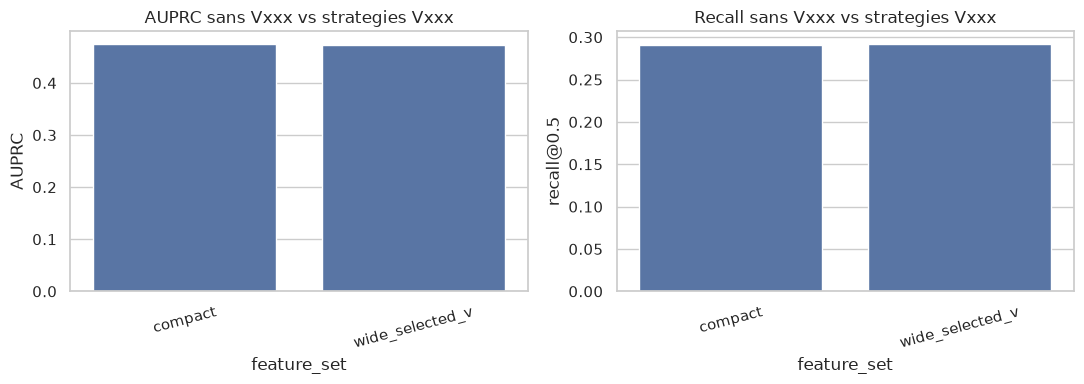

Vxxx utilisees pour wide_selected_v :


,feature,corr_with_isFraud_train,abs_corr,nonnull_rate_train
0,V257,0.3769,0.3769,0.2327
1,V244,0.3627,0.3627,0.2327
2,V242,0.3579,0.3579,0.2327
3,V246,0.3571,0.3571,0.2327
4,V233,0.3210,0.3210,0.2327
...,...,...,...,...
287,V241,-0.0016,0.0016,0.2327
288,V1,0.0012,0.0012,0.4793
289,V305,-0.0006,0.0006,1.0000
290,V209,-0.0005,0.0005,0.2469


In [6]:
# Par defaut on compare compact vs Vxxx selectionnees.
# Pour tester le troisieme mode, ajoute "wide_v_blocks" dans COMPARISON_FEATURE_SETS.
COMPARISON_FEATURE_SETS = COMPARISON_FEATURE_SETS


def build_feature_set(feature_set_name):
    compact_numeric_features = [col for col in compact_numeric_candidates if col in train.columns]
    selected_v_features = []
    v_selection_table = None

    if feature_set_name == "compact":
        numeric_features_local = compact_numeric_features
    elif feature_set_name == "wide_selected_v":
        v_cols = [col for col in train.columns if col.startswith("V") and col[1:].isdigit()]
        split_idx_for_selection = int(train.height * (1 - VALID_SIZE))
        train_for_v_selection = train.slice(0, split_idx_for_selection)

        v_nonnull_rates = train_for_v_selection.select([
            pl.col(col).is_not_null().mean().alias(col) for col in v_cols
        ]).to_dicts()[0]
        usable_v_cols = [col for col in v_cols if v_nonnull_rates[col] >= 0.20]

        v_corr_rows = []
        for col in usable_v_cols:
            value = train_for_v_selection.select(pl.corr(col, "isFraud").alias("corr")).item()
            if value is not None and not np.isnan(value):
                v_corr_rows.append((col, value, abs(value), v_nonnull_rates[col]))

        v_selection_table = pl.DataFrame(
            v_corr_rows,
            schema=["feature", "corr_with_isFraud_train", "abs_corr", "nonnull_rate_train"],
            orient="row",
        ).sort("abs_corr", descending=True)
        selected_v_features = v_selection_table.head(TOP_V_FEATURES)["feature"].to_list()
        numeric_features_local = list(dict.fromkeys(compact_numeric_features + selected_v_features))
    elif feature_set_name == "wide_v_blocks":
        selected_v_features = [col for col in V_BLOCK_REPRESENTATIVE_FEATURES if col in train.columns]
        numeric_features_local = list(dict.fromkeys(compact_numeric_features + selected_v_features))
        v_selection_table = pl.DataFrame({
            "feature": selected_v_features,
            "selection_method": ["block_representative"] * len(selected_v_features),
        })
    else:
        raise ValueError(f"Feature set non supporte pour la comparaison : {feature_set_name}")

    categorical_features_local = [col for col in candidate_categorical_features if col in train.columns]
    feature_cols_local = list(dict.fromkeys(numeric_features_local + categorical_features_local + engineered_features))
    return feature_cols_local, numeric_features_local, categorical_features_local, selected_v_features, v_selection_table


def train_xgboost_feature_set(feature_set_name):
    feature_cols_local, numeric_features_local, categorical_features_local, selected_v_features, v_selection_table = build_feature_set(feature_set_name)
    model_columns_local = list(dict.fromkeys(feature_cols_local + ["isFraud", "day_rel"]))

    split_idx_local = int(train.height * (1 - VALID_SIZE))
    train_pd_local = train.slice(0, split_idx_local).select(model_columns_local).to_pandas()
    valid_pd_local = train.slice(split_idx_local, train.height - split_idx_local).select(model_columns_local).to_pandas()

    X_train_local = train_pd_local[feature_cols_local]
    y_train_local = train_pd_local["isFraud"].astype(int)
    X_valid_local = valid_pd_local[feature_cols_local]
    y_valid_local = valid_pd_local["isFraud"].astype(int)

    numeric_features_final_local = X_train_local.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features_final_local = [col for col in feature_cols_local if col not in numeric_features_final_local]

    preprocess_local = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]), numeric_features_final_local),
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
            ]), categorical_features_final_local),
        ],
        remainder="drop",
    )

    start = time.time()
    X_train_prepared_local = preprocess_local.fit_transform(X_train_local)
    X_valid_prepared_local = preprocess_local.transform(X_valid_local)

    model = XGBClassifier(**BASE_XGB_PARAMS)
    model.fit(X_train_prepared_local, y_train_local)
    train_time = time.time() - start

    scores = model.predict_proba(X_valid_prepared_local)[:, 1]
    preds = (scores >= DECISION_THRESHOLD).astype(int)

    row = {
        "feature_set": feature_set_name,
        "n_features": len(feature_cols_local),
        "n_vxxx_features": len(selected_v_features),
        "n_non_vxxx_features": len(feature_cols_local) - len(selected_v_features),
        "AUPRC": average_precision_score(y_valid_local, scores),
        f"precision@{DECISION_THRESHOLD}": precision_score(y_valid_local, preds, zero_division=0),
        f"recall@{DECISION_THRESHOLD}": recall_score(y_valid_local, preds, zero_division=0),
        f"F1@{DECISION_THRESHOLD}": f1_score(y_valid_local, preds, zero_division=0),
        "alert_rate": float(preds.mean()),
        "train_time_sec": train_time,
        "selected_vxxx_examples": ", ".join(selected_v_features[:10]),
    }

    del train_pd_local, valid_pd_local, X_train_local, X_valid_local
    del X_train_prepared_local, X_valid_prepared_local, model
    gc.collect()
    return row, v_selection_table


comparison_rows = []
v_selection_tables = {}
for feature_set_name in COMPARISON_FEATURE_SETS:
    print(f"\n=== Entrainement comparaison : {feature_set_name} ===")
    row, v_selection_table = train_xgboost_feature_set(feature_set_name)
    comparison_rows.append(row)
    if v_selection_table is not None:
        v_selection_tables[feature_set_name] = v_selection_table
    print(row)

compact_vs_vxxx_df = pd.DataFrame(comparison_rows)
if "compact" in compact_vs_vxxx_df["feature_set"].values:
    base_auprc = compact_vs_vxxx_df.loc[compact_vs_vxxx_df["feature_set"] == "compact", "AUPRC"].iloc[0]
    compact_vs_vxxx_df["AUPRC_gain_vs_compact"] = compact_vs_vxxx_df["AUPRC"] - base_auprc

print("Comparaison directe sans Vxxx / avec Vxxx :")
display(compact_vs_vxxx_df)

comparison_path = PROJECT_ROOT / "docs" / "compact_vs_vxxx_comparison.csv"
compact_vs_vxxx_df.to_csv(comparison_path, index=False)
print(f"Comparaison sauvegardee : {comparison_path}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=compact_vs_vxxx_df, x="feature_set", y="AUPRC", ax=axes[0])
axes[0].set_title("AUPRC sans Vxxx vs strategies Vxxx")
axes[0].tick_params(axis="x", rotation=15)

recall_col = f"recall@{DECISION_THRESHOLD}"
sns.barplot(data=compact_vs_vxxx_df, x="feature_set", y=recall_col, ax=axes[1])
axes[1].set_title("Recall sans Vxxx vs strategies Vxxx")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
save_plot("02_compact_vs_vxxx_comparison.png")
plt.show()

for name, table in v_selection_tables.items():
    print(f"Vxxx utilisees pour {name} :")
    display(table.head(max(TOP_V_FEATURES, len(table))).to_pandas())


## 5. Split temporel train / validation

Le split est fait apres tri par `TransactionDT`. La validation represente le futur. C'est indispensable pour eviter un score artificiellement optimiste.


In [7]:
# On deduplique car day_rel peut deja etre present dans feature_cols.
model_columns = list(dict.fromkeys(feature_cols + ["isFraud", "day_rel"]))

# On evite de convertir tout le dataset en pandas d'un coup : c'est souvent la cause du crash kernel.
split_idx = int(train.height * (1 - VALID_SIZE))
train_pd = train.slice(0, split_idx).select(model_columns).to_pandas()
valid_pd = train.slice(split_idx, train.height - split_idx).select(model_columns).to_pandas()

X_train = train_pd[feature_cols]
y_train = train_pd["isFraud"].astype(int)
X_valid = valid_pd[feature_cols]
y_valid = valid_pd["isFraud"].astype(int)

print(f"Train : {X_train.shape}, jours {train_pd['day_rel'].min()} -> {train_pd['day_rel'].max()}")
print(f"Valid : {X_valid.shape}, jours {valid_pd['day_rel'].min()} -> {valid_pd['day_rel'].max()}")
print(f"Taux fraude train : {y_train.mean():.4%}")
print(f"Taux fraude valid : {y_valid.mean():.4%}")

# A partir d'ici, on travaille en pandas/numpy pour sklearn/xgboost.
del train
gc.collect()


Train : (472432, 59), jours 1 -> 141
Valid : (118108, 59), jours 141 -> 182
Taux fraude train : 3.5135%
Taux fraude valid : 3.4409%


0

## 6. Preprocessing ajuste uniquement sur le train

On encode les categories avec `OrdinalEncoder`. Pour XGBoost, c'est souvent suffisant comme baseline. On n'utilise pas `OneHotEncoder` ici pour eviter une matrice trop large avec SMOTE.

Important : le preprocessor est `fit` sur le train seulement, puis applique a la validation. Cela evite une fuite de donnees.


In [8]:
numeric_features_final = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features_final = [col for col in feature_cols if col not in numeric_features_final]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features_final),
        ("cat", categorical_pipeline, categorical_features_final),
    ],
    remainder="drop",
)

start = time.time()
X_train_prepared = preprocess.fit_transform(X_train)
X_valid_prepared = preprocess.transform(X_valid)
print(f"Preprocessing termine en {time.time() - start:.1f} secondes")
print(f"X_train_prepared : {X_train_prepared.shape}")
print(f"X_valid_prepared : {X_valid_prepared.shape}")


Preprocessing termine en 6.3 secondes
X_train_prepared : (472432, 59)
X_valid_prepared : (118108, 59)


## 6 bis. Où les modèles sont créés et pourquoi

Dans ce notebook, les modèles sont créés à trois endroits logiques :

| Emplacement | Modèle créé | Pourquoi |
|---|---|---|
| Section stratégies | Plusieurs `XGBClassifier` | Comparer baseline, `scale_pos_weight`, undersampling, SMOTE, SMOTEENN avec les mêmes features |
| Section Optuna | Plusieurs `XGBClassifier` temporaires | Tester automatiquement plusieurs hyperparamètres et choisir ceux qui maximisent l'AUPRC |
| Modèle final tuné | Un `XGBClassifier` avec les meilleurs paramètres | Comparer proprement baseline vs modèle optimisé |

Important : les stratégies de resampling ne changent pas l'architecture du modèle. Elles changent surtout les données vues pendant l'entraînement. Optuna, lui, ne change pas les données : il cherche de meilleurs hyperparamètres pour XGBoost.


## 7. Fonctions d'entrainement et d'evaluation

Toutes les strategies passent par la meme fonction d'evaluation. On garde les scores probabilistes pour AUPRC, puis on applique un seuil de 0.5 pour recall et F1.


In [9]:
def evaluate_predictions(y_true, scores, threshold=0.5):
    preds = (scores >= threshold).astype(int)
    return {
        "AUPRC": average_precision_score(y_true, scores),
        "precision@0.5": precision_score(y_true, preds, zero_division=0),
        "recall@0.5": recall_score(y_true, preds, zero_division=0),
        "F1@0.5": f1_score(y_true, preds, zero_division=0),
        "predicted_positive_rate": preds.mean(),
        "true_fraud_rate": np.mean(y_true),
    }


def train_xgb_strategy(name, X_tr, y_tr, X_val, y_val, sampler=None, xgb_params=None):
    # Le sampler est applique uniquement sur le train deja transforme.
    params = dict(BASE_XGB_PARAMS)
    if xgb_params:
        params.update(xgb_params)

    start = time.time()
    X_fit, y_fit = X_tr, y_tr

    if sampler is not None:
        X_fit, y_fit = sampler.fit_resample(X_tr, y_tr)

    model = XGBClassifier(**params)
    model.fit(X_fit, y_fit)
    train_time = time.time() - start

    scores = model.predict_proba(X_val)[:, 1]
    metrics = evaluate_predictions(y_val, scores, threshold=DECISION_THRESHOLD)
    metrics.update({
        "strategy": name,
        "train_time_sec": train_time,
        "train_rows_after_sampling": len(y_fit),
        "fraud_rate_after_sampling": float(np.mean(y_fit)),
    })

    return model, scores, metrics


## 8. Donnees pour les strategies de resampling

SMOTE et SMOTEENN peuvent etre lents sur le dataset complet. Si `MAX_TRAIN_ROWS_FOR_RESAMPLING` est defini, on prend les lignes les plus recentes du train pour conserver la logique temporelle.


In [10]:
if MAX_TRAIN_ROWS_FOR_RESAMPLING is not None and len(y_train) > MAX_TRAIN_ROWS_FOR_RESAMPLING:
    start_row = len(y_train) - MAX_TRAIN_ROWS_FOR_RESAMPLING
    X_train_for_sampling = X_train_prepared[start_row:]
    y_train_for_sampling = y_train.iloc[start_row:].to_numpy()
    print(f"Train limite pour resampling : {X_train_for_sampling.shape}")
else:
    X_train_for_sampling = X_train_prepared
    y_train_for_sampling = y_train.to_numpy()
    print(f"Train complet pour resampling : {X_train_for_sampling.shape}")

y_valid_np = y_valid.to_numpy()

neg_count = (y_train.to_numpy() == 0).sum()
pos_count = (y_train.to_numpy() == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"scale_pos_weight recommande : {scale_pos_weight:.2f}")


Train limite pour resampling : (150000, 59)
scale_pos_weight recommande : 27.46


## 9. Entrainement des strategies

On entraine les 5 strategies demandees. Si SMOTEENN est trop lent, execute les cellules jusqu'a SMOTE, puis relance SMOTEENN avec `MAX_TRAIN_ROWS_FOR_RESAMPLING = 100_000`.


In [11]:
models = {}
scores_by_strategy = {}
results = []


In [12]:
model, scores, metrics = train_xgb_strategy(
    name="xgboost_baseline",
    X_tr=X_train_prepared,
    y_tr=y_train.to_numpy(),
    X_val=X_valid_prepared,
    y_val=y_valid_np,
)
models[metrics["strategy"]] = model
scores_by_strategy[metrics["strategy"]] = scores
results.append(metrics)
display(pd.DataFrame(results).sort_values("AUPRC", ascending=False))


,AUPRC,precision@0.5,recall@0.5,F1@0.5,predicted_positive_rate,true_fraud_rate,strategy,train_time_sec,train_rows_after_sampling,fraud_rate_after_sampling
0,0.4753,0.7628,0.2904,0.4206,0.0131,0.0344,xgboost_baseline,5.8325,472432,0.0351


In [13]:
model, scores, metrics = train_xgb_strategy(
    name="xgboost_scale_pos_weight",
    X_tr=X_train_prepared,
    y_tr=y_train.to_numpy(),
    X_val=X_valid_prepared,
    y_val=y_valid_np,
    xgb_params={"scale_pos_weight": scale_pos_weight},
)
models[metrics["strategy"]] = model
scores_by_strategy[metrics["strategy"]] = scores
results.append(metrics)
display(pd.DataFrame(results).sort_values("AUPRC", ascending=False))


,AUPRC,precision@0.5,recall@0.5,F1@0.5,predicted_positive_rate,true_fraud_rate,strategy,train_time_sec,train_rows_after_sampling,fraud_rate_after_sampling
0,0.4753,0.7628,0.2904,0.4206,0.0131,0.0344,xgboost_baseline,5.8325,472432,0.0351
1,0.4525,0.1585,0.7576,0.2621,0.1645,0.0344,xgboost_scale_pos_weight,5.3093,472432,0.0351


In [14]:
model, scores, metrics = train_xgb_strategy(
    name="random_undersampling",
    X_tr=X_train_for_sampling,
    y_tr=y_train_for_sampling,
    X_val=X_valid_prepared,
    y_val=y_valid_np,
    sampler=RandomUnderSampler(random_state=RANDOM_STATE),
)
models[metrics["strategy"]] = model
scores_by_strategy[metrics["strategy"]] = scores
results.append(metrics)
display(pd.DataFrame(results).sort_values("AUPRC", ascending=False))


,AUPRC,precision@0.5,recall@0.5,F1@0.5,predicted_positive_rate,true_fraud_rate,strategy,train_time_sec,train_rows_after_sampling,fraud_rate_after_sampling
0,0.4753,0.7628,0.2904,0.4206,0.0131,0.0344,xgboost_baseline,5.8325,472432,0.0351
1,0.4525,0.1585,0.7576,0.2621,0.1645,0.0344,xgboost_scale_pos_weight,5.3093,472432,0.0351
2,0.4523,0.1654,0.7544,0.2713,0.1570,0.0344,random_undersampling,1.1160,11278,0.5000


In [15]:
model, scores, metrics = train_xgb_strategy(
    name="smote",
    X_tr=X_train_for_sampling,
    y_tr=y_train_for_sampling,
    X_val=X_valid_prepared,
    y_val=y_valid_np,
    sampler=SMOTE(random_state=RANDOM_STATE, k_neighbors=5),
)
models[metrics["strategy"]] = model
scores_by_strategy[metrics["strategy"]] = scores
results.append(metrics)
display(pd.DataFrame(results).sort_values("AUPRC", ascending=False))


,AUPRC,precision@0.5,recall@0.5,F1@0.5,predicted_positive_rate,true_fraud_rate,strategy,train_time_sec,train_rows_after_sampling,fraud_rate_after_sampling
0,0.4753,0.7628,0.2904,0.4206,0.0131,0.0344,xgboost_baseline,5.8325,472432,0.0351
1,0.4525,0.1585,0.7576,0.2621,0.1645,0.0344,xgboost_scale_pos_weight,5.3093,472432,0.0351
2,0.4523,0.1654,0.7544,0.2713,0.1570,0.0344,random_undersampling,1.1160,11278,0.5000
3,0.4137,0.4245,0.4240,0.4242,0.0344,0.0344,smote,5.9692,288722,0.5000


In [16]:
model, scores, metrics = train_xgb_strategy(
    name="smoteenn",
    X_tr=X_train_for_sampling,
    y_tr=y_train_for_sampling,
    X_val=X_valid_prepared,
    y_val=y_valid_np,
    sampler=SMOTEENN(random_state=RANDOM_STATE),
)
models[metrics["strategy"]] = model
scores_by_strategy[metrics["strategy"]] = scores
results.append(metrics)
display(pd.DataFrame(results).sort_values("AUPRC", ascending=False))


,AUPRC,precision@0.5,recall@0.5,F1@0.5,predicted_positive_rate,true_fraud_rate,strategy,train_time_sec,train_rows_after_sampling,fraud_rate_after_sampling
0,0.4753,0.7628,0.2904,0.4206,0.0131,0.0344,xgboost_baseline,5.8325,472432,0.0351
1,0.4525,0.1585,0.7576,0.2621,0.1645,0.0344,xgboost_scale_pos_weight,5.3093,472432,0.0351
2,0.4523,0.1654,0.7544,0.2713,0.1570,0.0344,random_undersampling,1.1160,11278,0.5000
4,0.4265,0.4097,0.4481,0.4280,0.0376,0.0344,smoteenn,123.2552,268243,0.5325
3,0.4137,0.4245,0.4240,0.4242,0.0344,0.0344,smote,5.9692,288722,0.5000


## 10. Tableau comparatif final

Le classement principal se fait par AUPRC, mais la decision metier doit aussi regarder le recall, le taux d'alertes et le temps d'entrainement.


In [17]:
results_df = pd.DataFrame(results)
ordered_cols = [
    "strategy", "AUPRC", "precision@0.5", "recall@0.5", "F1@0.5",
    "predicted_positive_rate", "true_fraud_rate", "train_time_sec",
    "train_rows_after_sampling", "fraud_rate_after_sampling",
]
results_df = results_df[ordered_cols].sort_values("AUPRC", ascending=False).reset_index(drop=True)
display(results_df)


,strategy,AUPRC,precision@0.5,recall@0.5,F1@0.5,predicted_positive_rate,true_fraud_rate,train_time_sec,train_rows_after_sampling,fraud_rate_after_sampling
0,xgboost_baseline,0.4753,0.7628,0.2904,0.4206,0.0131,0.0344,5.8325,472432,0.0351
1,xgboost_scale_pos_weight,0.4525,0.1585,0.7576,0.2621,0.1645,0.0344,5.3093,472432,0.0351
2,random_undersampling,0.4523,0.1654,0.7544,0.2713,0.1570,0.0344,1.1160,11278,0.5000
3,smoteenn,0.4265,0.4097,0.4481,0.4280,0.0376,0.0344,123.2552,268243,0.5325
4,smote,0.4137,0.4245,0.4240,0.4242,0.0344,0.0344,5.9692,288722,0.5000


Figure sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/assets/02_model_strategy_comparison.png


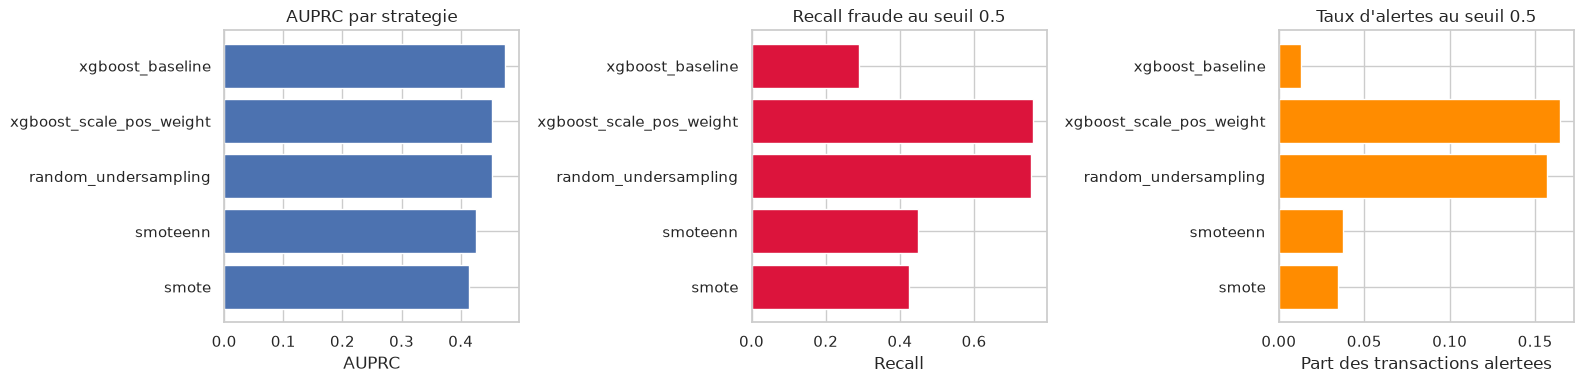

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_df = results_df.sort_values("AUPRC", ascending=True)

axes[0].barh(plot_df["strategy"], plot_df["AUPRC"])
axes[0].set_title("AUPRC par strategie")
axes[0].set_xlabel("AUPRC")

axes[1].barh(plot_df["strategy"], plot_df["recall@0.5"], color="crimson")
axes[1].set_title("Recall fraude au seuil 0.5")
axes[1].set_xlabel("Recall")

axes[2].barh(plot_df["strategy"], plot_df["predicted_positive_rate"], color="darkorange")
axes[2].set_title("Taux d'alertes au seuil 0.5")
axes[2].set_xlabel("Part des transactions alertees")

plt.tight_layout()
save_plot("02_model_strategy_comparison.png")
plt.show()


## 11. Courbes Precision-Recall

Ces courbes permettent de choisir un seuil adapte au contexte metier. Un seuil de 0.5 n'est pas forcement optimal en fraude.


Figure sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/assets/02_precision_recall_curves.png


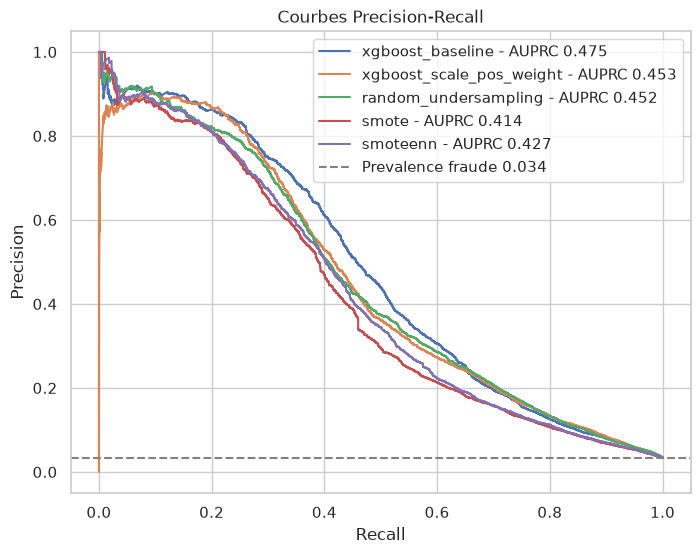

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
for strategy, scores in scores_by_strategy.items():
    precision, recall, _ = precision_recall_curve(y_valid_np, scores)
    auprc = average_precision_score(y_valid_np, scores)
    ax.plot(recall, precision, label=f"{strategy} - AUPRC {auprc:.3f}")

ax.axhline(y_valid_np.mean(), color="gray", linestyle="--", label=f"Prevalence fraude {y_valid_np.mean():.3f}")
ax.set_title("Courbes Precision-Recall")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="best")
save_plot("02_precision_recall_curves.png")
plt.show()


## 12. Matrice de confusion du meilleur modele

On affiche la matrice de confusion du modele avec la meilleure AUPRC. Pour une recommandation finale, il faudra probablement ajuster le seuil en fonction de la capacite des analystes et du cout des faux negatifs.


Meilleure strategie par AUPRC : xgboost_baseline
              precision    recall  f1-score   support

    legitime       0.98      1.00      0.99    114044
      fraude       0.76      0.29      0.42      4064

    accuracy                           0.97    118108
   macro avg       0.87      0.64      0.70    118108
weighted avg       0.97      0.97      0.97    118108

Figure sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/assets/02_confusion_matrix_xgboost_baseline.png


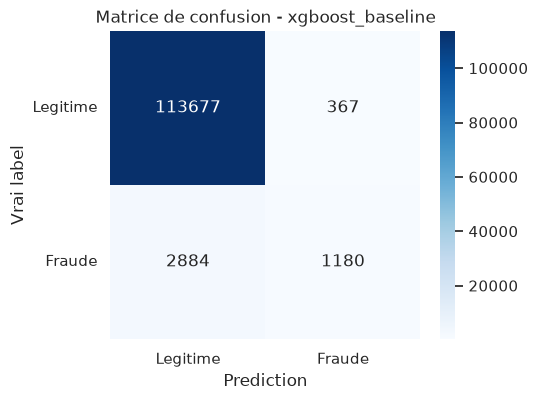

In [20]:
best_strategy = results_df.iloc[0]["strategy"]
best_scores = scores_by_strategy[best_strategy]
best_pred = (best_scores >= DECISION_THRESHOLD).astype(int)

print(f"Meilleure strategie par AUPRC : {best_strategy}")
print(classification_report(y_valid_np, best_pred, target_names=["legitime", "fraude"], zero_division=0))

cm = confusion_matrix(y_valid_np, best_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title(f"Matrice de confusion - {best_strategy}")
ax.set_xlabel("Prediction")
ax.set_ylabel("Vrai label")
ax.set_xticklabels(["Legitime", "Fraude"])
ax.set_yticklabels(["Legitime", "Fraude"], rotation=0)
save_plot(f"02_confusion_matrix_{best_strategy}.png")
plt.show()


## 13. Ajustement du seuil metier

Le seuil 0.5 est arbitraire. En production, PayTrack doit choisir un seuil selon :
- le cout d'une fraude manquee ;
- le cout d'un faux positif ;
- la capacite quotidienne des analystes ;
- le niveau de friction acceptable pour les clients.

La cellule suivante compare plusieurs seuils pour le meilleur modele.


,threshold,precision,recall,F1,alert_rate,alerts_count
0,0.0500,0.1738,0.7315,0.2808,0.1449,17109
1,0.1000,0.3156,0.5898,0.4112,0.0643,7595
2,0.1500,0.4234,0.5076,0.4617,0.0413,4873
3,0.2000,0.5070,0.4545,0.4793,0.0308,3643
4,0.2500,0.5843,0.4129,0.4839,0.0243,2872
5,0.3000,0.6373,0.3895,0.4835,0.0210,2484
6,0.3500,0.6743,0.3607,0.4700,0.0184,2174
7,0.4000,0.7159,0.3349,0.4563,0.0161,1901
8,0.4500,0.7422,0.3118,0.4391,0.0145,1707
9,0.5000,0.7628,0.2904,0.4206,0.0131,1547


Figure sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/assets/02_threshold_impact_xgboost_baseline.png


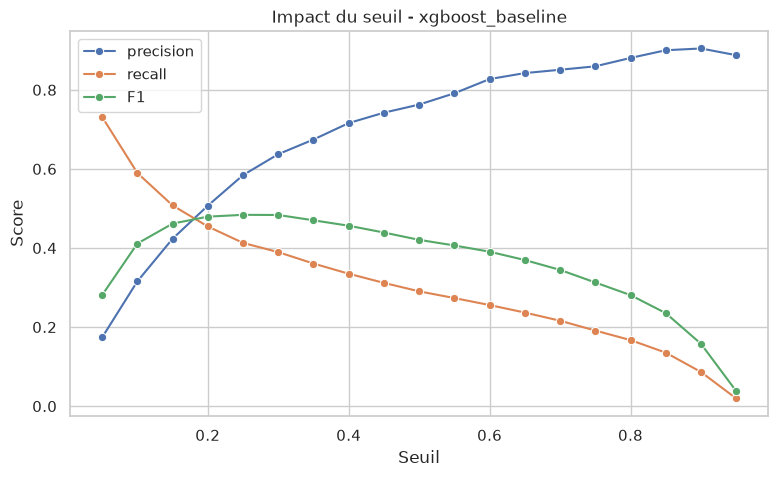

In [21]:
threshold_rows = []
for threshold in np.linspace(0.05, 0.95, 19):
    preds = (best_scores >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_valid_np, preds, zero_division=0),
        "recall": recall_score(y_valid_np, preds, zero_division=0),
        "F1": f1_score(y_valid_np, preds, zero_division=0),
        "alert_rate": preds.mean(),
        "alerts_count": preds.sum(),
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=threshold_df, x="threshold", y="precision", marker="o", label="precision", ax=ax)
sns.lineplot(data=threshold_df, x="threshold", y="recall", marker="o", label="recall", ax=ax)
sns.lineplot(data=threshold_df, x="threshold", y="F1", marker="o", label="F1", ax=ax)
ax.set_title(f"Impact du seuil - {best_strategy}")
ax.set_xlabel("Seuil")
ax.set_ylabel("Score")
save_plot(f"02_threshold_impact_{best_strategy}.png")
plt.show()


## 13 bis. Hypertuning XGBoost avec Optuna

On tune uniquement le **XGBoost baseline**, car c'est le meilleur compromis actuel. L'objectif est de maximiser l'**AUPRC** sur la validation temporelle.

Pourquoi Optuna plutôt qu'un GridSearch :

- XGBoost a beaucoup d'hyperparamètres, donc une grille complète devient vite trop lente ;
- Optuna explore l'espace de recherche plus efficacement ;
- on peut limiter le nombre d'essais avec `OPTUNA_N_TRIALS`.

Le split reste temporel : le tuning utilise le passé pour entraîner et le futur pour valider. On évite donc une validation random qui pourrait être trop optimiste.


In [22]:
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
    print(f"Optuna disponible : {optuna.__version__}")
except ImportError:
    OPTUNA_AVAILABLE = False
    print("Optuna n'est pas installe dans ce kernel.")
    print("Installe-le avec : pip install optuna")


Optuna disponible : 4.9.0


In [23]:
optuna_results_df = None
tuned_model = None
tuned_scores = None
tuned_metrics = None

if OPTUNA_AVAILABLE:
    def objective(trial):
        params = dict(BASE_XGB_PARAMS)
        params.update({
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "subsample": trial.suggest_float("subsample", 0.60, 1.00),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 20.0, log=True),
        })

        model_trial = XGBClassifier(**params)
        model_trial.fit(X_train_prepared, y_train.to_numpy())
        scores = model_trial.predict_proba(X_valid_prepared)[:, 1]
        return average_precision_score(y_valid_np, scores)

    study = optuna.create_study(direction="maximize", study_name="xgboost_auprc_temporal")
    start = time.time()
    study.optimize(objective, n_trials=OPTUNA_N_TRIALS, timeout=OPTUNA_TIMEOUT, show_progress_bar=True)
    tuning_time = time.time() - start

    print(f"Meilleure AUPRC Optuna : {study.best_value:.4f}")
    print("Meilleurs params :")
    print(study.best_params)
    print(f"Temps tuning : {tuning_time:.1f} secondes")

    optuna_results_df = study.trials_dataframe().sort_values("value", ascending=False).reset_index(drop=True)
    display(optuna_results_df.head(10))
else:
    print("Hypertuning ignore : installe optuna puis relance cette section.")


Best trial: 13. Best value: 0.542424: 100%|██████████| 25/25 [05:10<00:00, 12.41s/it]

Meilleure AUPRC Optuna : 0.5424
Meilleurs params :
{'n_estimators': 292, 'max_depth': 8, 'learning_rate': 0.08515747724292518, 'subsample': 0.9963094845259302, 'colsample_bytree': 0.9308164708511706, 'min_child_weight': 5, 'gamma': 1.179197341302329, 'reg_alpha': 4.552759865547368e-07, 'reg_lambda': 0.014595367488846333}
Temps tuning : 310.3 secondes


,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_reg_alpha,params_reg_lambda,params_subsample,state
0,13,0.5424,2026-06-26 14:43:42.359011,2026-06-26 14:43:59.823676,0 days 00:00:17.464665,0.9308,1.1792,0.0852,8,5,292,0.0000,0.0146,0.9963,COMPLETE
1,24,0.5395,2026-06-26 14:46:05.043081,2026-06-26 14:46:23.004243,0 days 00:00:17.961162,0.8483,0.8658,0.0702,8,4,299,0.0000,0.0046,0.8506,COMPLETE
2,22,0.5387,2026-06-26 14:45:35.406006,2026-06-26 14:45:50.917337,0 days 00:00:15.511331,0.8857,1.0569,0.0727,8,5,306,0.0001,0.0013,0.9680,COMPLETE
3,21,0.5340,2026-06-26 14:45:22.065050,2026-06-26 14:45:35.402558,0 days 00:00:13.337508,0.8741,1.1896,0.0839,8,6,307,0.0000,0.0013,0.9957,COMPLETE
4,14,0.5309,2026-06-26 14:43:59.826054,2026-06-26 14:44:12.462127,0 days 00:00:12.636073,0.8813,1.3553,0.0893,8,5,208,0.0000,0.0011,0.9969,COMPLETE
5,15,0.5303,2026-06-26 14:44:12.465891,2026-06-26 14:44:25.423064,0 days 00:00:12.957173,0.8689,1.4782,0.0813,8,6,283,0.0000,0.0014,0.9996,COMPLETE
6,17,0.5272,2026-06-26 14:44:39.555270,2026-06-26 14:44:49.585094,0 days 00:00:10.029824,0.8887,3.0651,0.1019,8,4,327,0.0000,0.0059,0.9993,COMPLETE
7,23,0.5236,2026-06-26 14:45:50.920794,2026-06-26 14:46:05.039947,0 days 00:00:14.119153,0.9143,1.0116,0.0491,7,7,342,0.0003,0.0112,0.9609,COMPLETE
8,5,0.5231,2026-06-26 14:42:27.604492,2026-06-26 14:42:34.935246,0 days 00:00:07.330754,0.9442,0.4773,0.1393,7,2,163,0.0000,0.3078,0.9579,COMPLETE
9,16,0.5212,2026-06-26 14:44:25.426561,2026-06-26 14:44:39.551431,0 days 00:00:14.124870,0.9988,2.2656,0.0406,8,5,255,0.0000,0.0063,0.9429,COMPLETE


In [24]:
if OPTUNA_AVAILABLE:
    tuned_params = dict(BASE_XGB_PARAMS)
    tuned_params.update(study.best_params)

    start = time.time()
    tuned_model = XGBClassifier(**tuned_params)
    tuned_model.fit(X_train_prepared, y_train.to_numpy())
    tuned_train_time = time.time() - start

    tuned_scores = tuned_model.predict_proba(X_valid_prepared)[:, 1]
    tuned_metrics = evaluate_predictions(y_valid_np, tuned_scores, threshold=DECISION_THRESHOLD)
    tuned_metrics.update({
        "strategy": "xgboost_optuna_tuned",
        "train_time_sec": tuned_train_time,
        "train_rows_after_sampling": len(y_train),
        "fraud_rate_after_sampling": float(y_train.mean()),
    })

    baseline_row = results_df[results_df["strategy"] == "xgboost_baseline"].iloc[0].to_dict()
    tuning_comparison_df = pd.DataFrame([
        baseline_row,
        {col: tuned_metrics.get(col, None) for col in results_df.columns},
    ])
    tuning_comparison_df["AUPRC_gain_vs_baseline"] = tuning_comparison_df["AUPRC"] - baseline_row["AUPRC"]

    display(tuning_comparison_df)

    tuning_path = PROJECT_ROOT / "docs" / "xgboost_optuna_tuning_comparison.csv"
    tuning_comparison_df.to_csv(tuning_path, index=False)
    print(f"Comparaison tuning sauvegardee : {tuning_path}")
else:
    print("Comparaison baseline vs tuned non disponible sans Optuna.")


,strategy,AUPRC,precision@0.5,recall@0.5,F1@0.5,predicted_positive_rate,true_fraud_rate,train_time_sec,train_rows_after_sampling,fraud_rate_after_sampling,AUPRC_gain_vs_baseline
0,xgboost_baseline,0.4753,0.7628,0.2904,0.4206,0.0131,0.0344,5.8325,472432,0.0351,0.0000
1,xgboost_optuna_tuned,0.5424,0.7721,0.3634,0.4942,0.0162,0.0344,12.7445,472432,0.0351,0.0671


Comparaison tuning sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/xgboost_optuna_tuning_comparison.csv


Figure sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/assets/02_xgboost_optuna_tuning_comparison.png


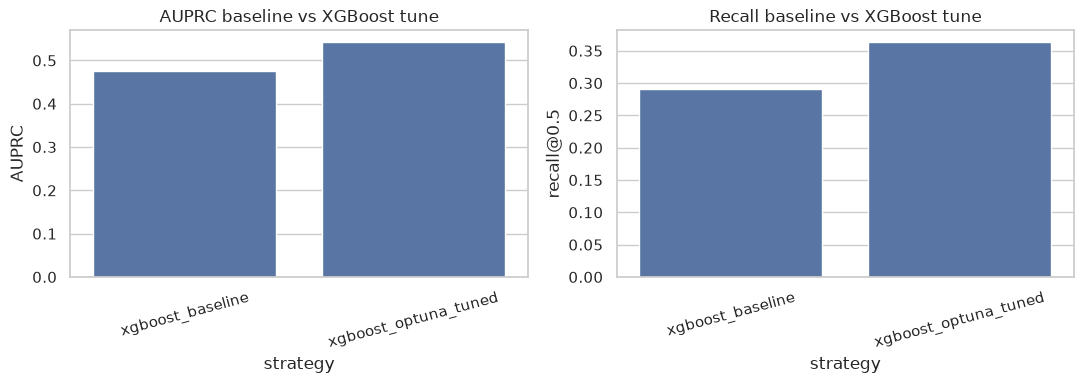

In [25]:
if OPTUNA_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    sns.barplot(data=tuning_comparison_df, x="strategy", y="AUPRC", ax=axes[0])
    axes[0].set_title("AUPRC baseline vs XGBoost tune")
    axes[0].tick_params(axis="x", rotation=15)

    sns.barplot(data=tuning_comparison_df, x="strategy", y="recall@0.5", ax=axes[1])
    axes[1].set_title("Recall baseline vs XGBoost tune")
    axes[1].tick_params(axis="x", rotation=15)

    plt.tight_layout()
    save_plot("02_xgboost_optuna_tuning_comparison.png")
    plt.show()
else:
    print("Graphique tuning non genere sans Optuna.")


### Lecture attendue du tuning

Si `xgboost_optuna_tuned` améliore clairement l'AUPRC, il devient le meilleur candidat modèle. Si le gain est nul ou faible, la baseline reste préférable car elle est plus simple, plus rapide et plus stable.

Dans tous les cas, il faut regarder l'AUPRC **et** le taux d'alertes : un modèle qui gagne un peu en recall mais multiplie les alertes peut être difficile à exploiter pour les analystes fraude.


## 14. Recommandation a rediger

A completer apres execution :

1. **Meilleure strategie par AUPRC** : `...`.
2. **Strategie avec meilleur recall** : `...`.
3. **Strategie la plus couteuse en alertes** : `...`.
4. **Strategie recommandee au CDO** : `...`.
5. **Justification metier** :
   - faux negatifs = fraudes manquees et chargebacks ;
   - faux positifs = clients legitimes bloques et charge analystes ;
   - un bon modele doit maximiser AUPRC/recall sans exploser le taux d'alertes.

Phrase type :

> Je recommande `...` car cette strategie obtient le meilleur compromis entre AUPRC, recall fraude et taux d'alertes. Le seuil de decision devra etre ajuste selon la capacite operationnelle des analystes, car le seuil 0.5 n'est pas automatiquement optimal en detection de fraude.


## 15. Prochaine etape

Apres ce notebook :

- ajouter des features graphe avec NetworkX sur un sous-ensemble client-marchand ;
- comparer XGBoost seul vs XGBoost + features graphe ;
- preparer le notebook MLOps avec MLflow, SHAP et Evidently.
